# Feature engineering and ML-ready TCSPC representations

This notebook investigates how TCSPC histograms can be represented for
machine-learning analysis.

The focus is not yet on predictive performance. Instead, we examine how
physically motivated features and histogram-based representations respond to:

- fluorescence lifetime;
- photon-count level;
- background;
- IRF width;
- IRF temporal shift.

The notebook will compare three representations:

1. engineered physical features;
2. total-normalized histogram bins;
3. PCA-compressed normalized histograms.

A central principle is that these representations must describe the same
underlying samples so that later machine-learning comparisons are meaningful.

Feature extraction is kept separate from preprocessing. In particular, the raw
histograms used below are not silently background-subtracted, normalized,
aligned, cropped, or rebinned before engineered features are calculated.

In [1]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from tcspc_toolkit.config import FeatureConfig, CountNormalization
from tcspc_toolkit.convolution import convolve_decay_with_irf
from tcspc_toolkit.features import (
    FEATURE_NAMES,
    extract_feature_table,
)
from tcspc_toolkit.irf import (
    generate_gaussian_irf,
    normalize_irf,
    shift_irf,
)
from tcspc_toolkit.models import monoexponential_decay
from tcspc_toolkit.simulation import sample_photon_counts
from tcspc_toolkit.representations import (
    cumulative_explained_variance,
    fit_pca_representation,
    normalize_histogram_batch,
    transform_pca_representation,
)

## Dataset design

To study feature behavior scientifically, we generate a structured synthetic
dataset rather than inspecting a single ideal decay.

The controlled variables are:

- **lifetime** — the target quantity of interest;
- **signal photon count** — the expected number of detected signal photons;
- **background** — expected background counts per histogram bin;
- **IRF FWHM** — temporal broadening introduced by the instrument response;
- **IRF shift** — temporal displacement of the instrument response.

The signal photon count and background are varied independently.

For each parameter combination:

1. a mono-exponential fluorescence decay is generated;
2. a Gaussian IRF is generated, normalized, and shifted;
3. the fluorescence decay is convolved with the IRF;
4. the convolved signal is scaled to the requested signal-photon count;
5. a constant background is added;
6. Poisson sampling produces the simulated measured histogram.

The amplitude of the initial mono-exponential model is therefore only a
temporary shape parameter. It is not treated as an additional nuisance
variable: the convolved signal is rescaled to the desired signal-photon count.

In [2]:
RANDOM_SEED = 42

TIME_START_NS = 0.0
TIME_STOP_NS = 20.0
BIN_WIDTH_NS = 0.05

IRF_CENTRE_NS = 1.0

time = np.arange(
    TIME_START_NS,
    TIME_STOP_NS,
    BIN_WIDTH_NS,
    dtype=np.float64,
)

lifetimes_ns = np.arange(
    0.5,
    5.0 + 0.5,
    0.5,
    dtype=np.float64,
)

signal_photon_counts = np.array(
    [
        5_000,
        25_000,
        100_000,
    ],
    dtype=np.int64,
)

background_levels = np.array(
    [
        0.0,
        0.5,
        2.0,
    ],
    dtype=np.float64,
)

irf_fwhm_values_ns = np.array(
    [
        0.15,
        0.30,
        0.60,
    ],
    dtype=np.float64,
)

irf_shift_values_ns = np.array(
    [
        -0.20,
        0.00,
        0.20,
    ],
    dtype=np.float64,
)

rng = np.random.default_rng(
    RANDOM_SEED
)

### IRF-convolved measurement simulation

The following notebook-local helper combines existing toolkit primitives.

The ideal decay is generated without background:

$$
I(t) = \exp(-t/\tau).
$$

The background is added only after IRF convolution. This is important because
a stationary detector background should not itself be convolved with the
instrument response.

After convolution, the signal shape is normalized by its discrete sum and
scaled to the requested expected signal-photon count:

$$
\mu_i^{(\mathrm{signal})}
=
N_{\mathrm{signal}}
\frac{s_i}{\sum_j s_j}.
$$

The final expected histogram is

$$
\mu_i
=
\mu_i^{(\mathrm{signal})}
+
B,
$$

where $B$ is the expected background count per bin.

Finally,

$$
N_i \sim \mathrm{Poisson}(\mu_i)
$$

produces the simulated measured histogram.

In [3]:
def simulate_irf_convolved_histogram(
    *,
    time: np.ndarray,
    lifetime_ns: float,
    signal_photon_count: int,
    background_per_bin: float,
    irf_fwhm_ns: float,
    irf_shift_ns: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, dict[str, float]]:
    """Simulate one IRF-convolved Poisson TCSPC histogram."""

    ideal_decay = monoexponential_decay(
        time=time,
        amplitude=1.0,
        lifetime=lifetime_ns,
        background=0.0,
    )

    irf = generate_gaussian_irf(
        time=time,
        centre=IRF_CENTRE_NS,
        fwhm=irf_fwhm_ns,
    )

    irf = normalize_irf(
        time=time,
        irf=irf,
    )

    irf = shift_irf(
        time=time,
        irf=irf,
        shift=irf_shift_ns,
    )

    # Re-normalize after shifting because interpolation on a finite
    # measurement window can slightly change the integrated IRF area.
    irf = normalize_irf(
        time=time,
        irf=irf,
    )

    convolved_signal = convolve_decay_with_irf(
        time=time,
        decay=ideal_decay,
        irf=irf,
    )

    signal_sum = convolved_signal.sum()

    if signal_sum <= 0.0:
        raise ValueError(
            "Convolved signal must have a positive discrete sum."
        )

    expected_signal = (
        float(signal_photon_count)
        * convolved_signal
        / signal_sum
    )

    expected_counts = (
        expected_signal
        + background_per_bin
    )

    measured_counts = sample_photon_counts(
        expected_counts=expected_counts,
        rng=rng,
    )

    simulation_metadata = {
        "lifetime_true_ns": lifetime_ns,
        "signal_photon_count_target": float(
            signal_photon_count
        ),
        "background_per_bin": background_per_bin,
        "irf_fwhm_ns": irf_fwhm_ns,
        "irf_shift_ns": irf_shift_ns,
        "expected_signal_counts": float(
            expected_signal.sum()
        ),
        "expected_background_counts": float(
            background_per_bin * time.size
        ),
        "expected_total_counts": float(
            expected_counts.sum()
        ),
        "measured_total_counts": float(
            measured_counts.sum()
        ),
    }

    return (
        measured_counts,
        simulation_metadata,
    )

In [4]:
histogram_rows = []
metadata_rows = []

parameter_grid = product(
    lifetimes_ns,
    signal_photon_counts,
    background_levels,
    irf_fwhm_values_ns,
    irf_shift_values_ns,
)

for curve_id, (
    lifetime_ns,
    signal_photon_count,
    background_per_bin,
    irf_fwhm_ns,
    irf_shift_ns,
) in enumerate(parameter_grid):

    measured_counts, sample_metadata = (
        simulate_irf_convolved_histogram(
            time=time,
            lifetime_ns=float(lifetime_ns),
            signal_photon_count=int(
                signal_photon_count
            ),
            background_per_bin=float(
                background_per_bin
            ),
            irf_fwhm_ns=float(
                irf_fwhm_ns
            ),
            irf_shift_ns=float(
                irf_shift_ns
            ),
            rng=rng,
        )
    )

    histogram_rows.append(
        measured_counts
    )

    metadata_rows.append(
        {
            "curve_id": curve_id,
            **sample_metadata,
        }
    )


histograms = np.vstack(
    histogram_rows
)

metadata = pd.DataFrame(
    metadata_rows
)

In [5]:
print(
    "Histogram matrix shape:",
    histograms.shape,
)

print(
    "Metadata shape:",
    metadata.shape,
)

print(
    "Histogram dtype:",
    histograms.dtype,
)

print(
    "Number of time bins:",
    time.size,
)

metadata.head()

Histogram matrix shape: (810, 400)
Metadata shape: (810, 10)
Histogram dtype: int64
Number of time bins: 400


,curve_id,lifetime_true_ns,signal_photon_count_target,background_per_bin,irf_fwhm_ns,irf_shift_ns,expected_signal_counts,expected_background_counts,expected_total_counts,measured_total_counts
0,0,0.5,5000.0,0.0,0.15,-0.2,5000.0,0.0,5000.0,4914.0
1,1,0.5,5000.0,0.0,0.15,0.0,5000.0,0.0,5000.0,4967.0
2,2,0.5,5000.0,0.0,0.15,0.2,5000.0,0.0,5000.0,4985.0
3,3,0.5,5000.0,0.0,0.30,-0.2,5000.0,0.0,5000.0,5113.0
4,4,0.5,5000.0,0.0,0.30,0.0,5000.0,0.0,5000.0,4886.0


In [6]:
assert histograms.shape[0] == len(metadata)
assert histograms.shape[1] == time.size

assert np.array_equal(
    metadata["curve_id"].to_numpy(),
    np.arange(len(metadata)),
)

assert np.issubdtype(
    histograms.dtype,
    np.integer,
)

## 1. Representative TCSPC curves

We first inspect measured histograms before calculating any derived features.

Three lifetimes are selected:

- short lifetime: $0.5\ \mathrm{ns}$;
- medium lifetime: $2.5\ \mathrm{ns}$;
- long lifetime: $5.0\ \mathrm{ns}$.

The same lifetime values are viewed under two different measurement regimes.

### Favorable regime

- 100,000 expected signal photons;
- zero background;
- IRF FWHM = 0.30 ns;
- zero IRF shift.

### Challenging regime

- 5,000 expected signal photons;
- background = 2 counts/bin;
- IRF FWHM = 0.60 ns;
- IRF shift = +0.20 ns.

These are raw Poisson-sampled histograms. They have not been normalized or
background-subtracted.

In [7]:
def find_curve_id(
    *,
    lifetime_ns: float,
    signal_photon_count: int,
    background_per_bin: float,
    irf_fwhm_ns: float,
    irf_shift_ns: float,
) -> int:
    """Return the unique curve ID for one parameter combination."""

    mask = (
        np.isclose(
            metadata["lifetime_true_ns"],
            lifetime_ns,
        )
        & np.isclose(
            metadata["signal_photon_count_target"],
            signal_photon_count,
        )
        & np.isclose(
            metadata["background_per_bin"],
            background_per_bin,
        )
        & np.isclose(
            metadata["irf_fwhm_ns"],
            irf_fwhm_ns,
        )
        & np.isclose(
            metadata["irf_shift_ns"],
            irf_shift_ns,
        )
    )

    curve_ids = metadata.loc[
        mask,
        "curve_id",
    ].to_numpy()

    if curve_ids.size != 1:
        raise ValueError(
            "Expected exactly one matching curve."
        )

    return int(
        curve_ids[0]
    )

In [8]:
representative_lifetimes_ns = [
    0.5,
    2.5,
    5.0,
]

favorable_curve_ids = [
    find_curve_id(
        lifetime_ns=lifetime_ns,
        signal_photon_count=100_000,
        background_per_bin=0.0,
        irf_fwhm_ns=0.30,
        irf_shift_ns=0.0,
    )
    for lifetime_ns in representative_lifetimes_ns
]

challenging_curve_ids = [
    find_curve_id(
        lifetime_ns=lifetime_ns,
        signal_photon_count=5_000,
        background_per_bin=2.0,
        irf_fwhm_ns=0.60,
        irf_shift_ns=0.20,
    )
    for lifetime_ns in representative_lifetimes_ns
]

representative_curve_ids = (
    favorable_curve_ids
    + challenging_curve_ids
)

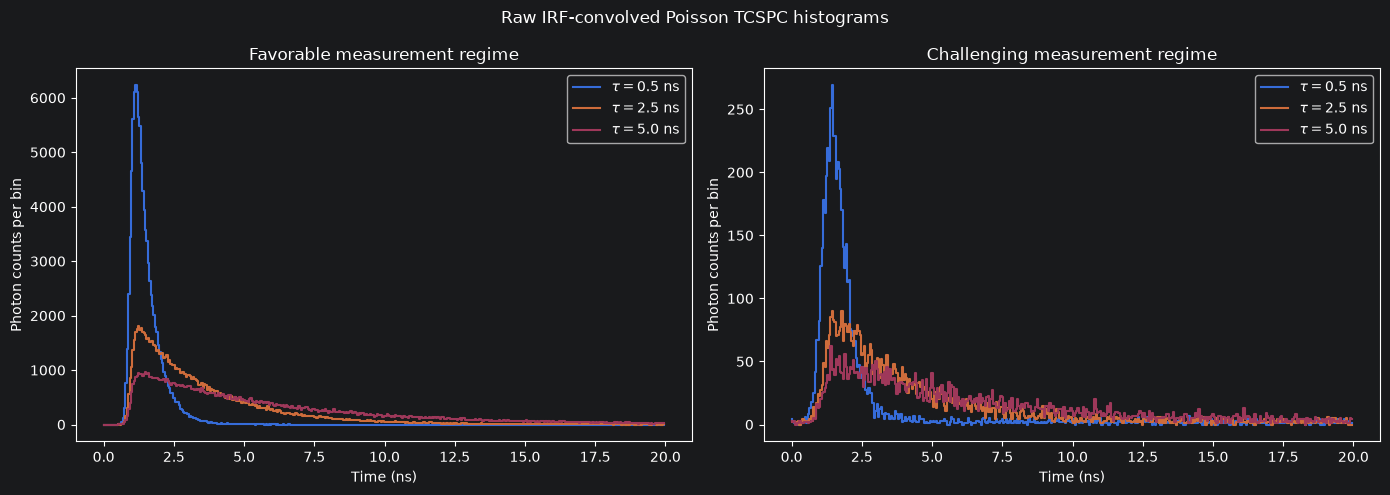

In [9]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharex=True,
)

for lifetime_ns, curve_id in zip(
    representative_lifetimes_ns,
    favorable_curve_ids,
):
    axes[0].plot(
        time,
        histograms[curve_id],
        drawstyle="steps-mid",
        label=rf"$\tau = {lifetime_ns:.1f}$ ns",
    )

axes[0].set_title(
    "Favorable measurement regime"
)
axes[0].set_xlabel(
    "Time (ns)"
)
axes[0].set_ylabel(
    "Photon counts per bin"
)
axes[0].legend()


for lifetime_ns, curve_id in zip(
    representative_lifetimes_ns,
    challenging_curve_ids,
):
    axes[1].plot(
        time,
        histograms[curve_id],
        drawstyle="steps-mid",
        label=rf"$\tau = {lifetime_ns:.1f}$ ns",
    )

axes[1].set_title(
    "Challenging measurement regime"
)
axes[1].set_xlabel(
    "Time (ns)"
)
axes[1].set_ylabel(
    "Photon counts per bin"
)
axes[1].legend()

fig.suptitle(
    "Raw IRF-convolved Poisson TCSPC histograms"
)

fig.tight_layout()

plt.show()

### Initial observations

Increasing lifetime redistributes photons toward later arrival times and
produces a more slowly decaying temporal tail.

However, the measured histogram is not determined by lifetime alone.

Lower photon counts increase Poisson fluctuations. Background raises the late
histogram baseline. A broader IRF changes the early-time temporal structure,
while an IRF shift moves the measured response along the time axis.

Consequently, a quantity that correlates strongly with lifetime under one
measurement condition may also respond to these nuisance variables.

The following sections quantify this behavior using engineered features.

These plots are descriptive only. They are not a measurement of estimator or
machine-learning performance.

## 2. Physically engineered features

We now transform each raw histogram into a compact set of physically motivated
descriptors.

A single fixed feature configuration is used for every histogram:

- tail region begins at 3.0 ns;
- the early-count region ends at 2.0 ns;
- the late-count region begins at 4.0 ns;
- at least 5 positive tail points are required for the log-tail regression.

The boundaries are deliberately not adapted using the known simulated
lifetime, IRF width, IRF shift, or background.

Doing so would make the feature definition depend on simulation metadata that
would not necessarily be known for an experimental measurement.

In [10]:
feature_config = FeatureConfig(
    tail_start_ns=3.0,
    early_stop_ns=2.0,
    late_start_ns=4.0,
    min_tail_points=5,
)

feature_config

FeatureConfig(tail_start_ns=3.0, early_stop_ns=2.0, late_start_ns=4.0, min_tail_points=5)

In [11]:
feature_table = extract_feature_table(
    histograms=histograms,
    time=time,
    config=feature_config,
)

print(
    "Feature matrix shape:",
    feature_table.shape,
)

feature_table.head()

Feature matrix shape: (810, 15)


,total_counts,peak_height,peak_time_ns,mean_arrival_time_ns,arrival_time_variance_ns2,arrival_time_skewness,t10_ns,t25_ns,t50_ns,t75_ns,t90_ns,half_decay_time_ns,tail_log_slope_per_ns,integrated_tail_fraction,early_late_count_ratio
0,4914.0,388.0,0.9,1.271032,0.246126,1.876843,0.794116,0.897616,1.103644,1.444153,1.889492,0.327586,-0.978256,0.012007,565.500000
1,4967.0,380.0,1.1,1.476364,0.255851,2.026552,0.996651,1.098257,1.299723,1.644500,2.109894,0.395652,-0.768364,0.018321,335.153846
2,4985.0,408.0,1.3,1.675075,0.250001,2.033107,1.203261,1.296844,1.505544,1.849100,2.288306,0.312500,-0.917498,0.026078,205.100000
3,5113.0,330.0,0.9,1.277616,0.269572,1.724887,0.769415,0.896402,1.106961,1.459432,1.946633,0.453448,-1.076771,0.014082,774.333333
4,4886.0,305.0,1.1,1.464337,0.262092,1.917142,0.961404,1.091885,1.304234,1.640035,2.090851,0.472024,-0.897272,0.018420,331.692308


In [12]:
assert len(feature_table) == len(metadata)

assert list(
    feature_table.columns
) == list(FEATURE_NAMES)

assert feature_table.shape == (
    histograms.shape[0],
    len(FEATURE_NAMES),
)

In [13]:
analysis_table = pd.concat(
    [
        metadata.reset_index(drop=True),
        feature_table.reset_index(drop=True),
    ],
    axis=1,
)

analysis_table.head()

,curve_id,lifetime_true_ns,signal_photon_count_target,background_per_bin,irf_fwhm_ns,irf_shift_ns,expected_signal_counts,expected_background_counts,expected_total_counts,measured_total_counts,...,arrival_time_skewness,t10_ns,t25_ns,t50_ns,t75_ns,t90_ns,half_decay_time_ns,tail_log_slope_per_ns,integrated_tail_fraction,early_late_count_ratio
0,0,0.5,5000.0,0.0,0.15,-0.2,5000.0,0.0,5000.0,4914.0,...,1.876843,0.794116,0.897616,1.103644,1.444153,1.889492,0.327586,-0.978256,0.012007,565.500000
1,1,0.5,5000.0,0.0,0.15,0.0,5000.0,0.0,5000.0,4967.0,...,2.026552,0.996651,1.098257,1.299723,1.644500,2.109894,0.395652,-0.768364,0.018321,335.153846
2,2,0.5,5000.0,0.0,0.15,0.2,5000.0,0.0,5000.0,4985.0,...,2.033107,1.203261,1.296844,1.505544,1.849100,2.288306,0.312500,-0.917498,0.026078,205.100000
3,3,0.5,5000.0,0.0,0.30,-0.2,5000.0,0.0,5000.0,5113.0,...,1.724887,0.769415,0.896402,1.106961,1.459432,1.946633,0.453448,-1.076771,0.014082,774.333333
4,4,0.5,5000.0,0.0,0.30,0.0,5000.0,0.0,5000.0,4886.0,...,1.917142,0.961404,1.091885,1.304234,1.640035,2.090851,0.472024,-0.897272,0.018420,331.692308


In [14]:
representative_metadata_columns = [
    "curve_id",
    "lifetime_true_ns",
    "signal_photon_count_target",
    "background_per_bin",
    "irf_fwhm_ns",
    "irf_shift_ns",
    "measured_total_counts",
]

analysis_table.loc[
    analysis_table["curve_id"].isin(
        representative_curve_ids
    ),
    representative_metadata_columns,
].round(3)

,curve_id,lifetime_true_ns,signal_photon_count_target,background_per_bin,irf_fwhm_ns,irf_shift_ns,measured_total_counts
26,26,0.5,5000.0,2.0,0.6,0.2,5764.0
58,58,0.5,100000.0,0.0,0.3,0.0,99493.0
350,350,2.5,5000.0,2.0,0.6,0.2,5872.0
382,382,2.5,100000.0,0.0,0.3,0.0,100308.0
755,755,5.0,5000.0,2.0,0.6,0.2,5750.0
787,787,5.0,100000.0,0.0,0.3,0.0,99937.0


In [15]:
representative_feature_columns = [
    "curve_id",
    "lifetime_true_ns",
    *FEATURE_NAMES,
]

representative_features = analysis_table.loc[
    analysis_table["curve_id"].isin(
        representative_curve_ids
    ),
    representative_feature_columns,
]

representative_features.round(4)

,curve_id,lifetime_true_ns,total_counts,peak_height,peak_time_ns,mean_arrival_time_ns,arrival_time_variance_ns2,arrival_time_skewness,t10_ns,t25_ns,t50_ns,t75_ns,t90_ns,half_decay_time_ns,tail_log_slope_per_ns,integrated_tail_fraction,early_late_count_ratio
26,26,0.5,5764.0,269.0,1.45,2.8131,12.8745,3.1243,1.0794,1.3108,1.6250,2.1439,5.6800,0.4191,-0.0388,0.1443,5.9985
58,58,0.5,99493.0,6230.0,1.15,1.4804,0.2719,1.8495,0.9663,1.1005,1.3154,1.6666,2.1266,0.4314,-1.6859,0.0197,311.8669
350,350,2.5,5872.0,90.0,1.45,4.5518,14.5774,1.9037,1.4134,1.9808,3.2170,5.5976,9.4690,1.4368,-0.1904,0.5439,0.6410
382,382,2.5,100308.0,1804.0,1.25,3.4533,5.9885,1.8456,1.2178,1.6724,2.6844,4.4019,6.6493,1.6743,-0.4059,0.4503,1.1409
755,755,5.0,5750.0,62.0,1.40,6.2011,20.3401,1.0917,1.6489,2.6631,4.7944,8.5325,13.2750,1.1469,-0.1646,0.7120,0.2633
787,787,5.0,99937.0,956.0,1.50,5.5662,16.7715,1.2160,1.4733,2.3616,4.3198,7.5882,11.6452,2.8885,-0.1979,0.6646,0.3550


### Physical interpretation of the engineered features

The engineered features describe different aspects of the measured photon
arrival distribution.

| Feature | Physical interpretation |
|---|---|
| `total_counts` | Total detected photons in the measurement window. Contains absolute intensity information and is affected by both signal photon count and background. |
| `peak_height` | Maximum photon count in a single time bin. Depends on absolute photon count, temporal broadening, lifetime, background, and binning. |
| `peak_time_ns` | Time position of the maximum histogram bin. Particularly sensitive to IRF position and temporal shifts, but noise and decay shape may also influence it. |
| `mean_arrival_time_ns` | Count-weighted mean photon-arrival time. Longer lifetimes generally move it later, but IRF shift, background, and finite acquisition windows also affect it. |
| `arrival_time_variance_ns2` | Temporal spread of the photon-arrival distribution around its mean. It responds to fluorescence decay width as well as IRF broadening and background. |
| `arrival_time_skewness` | Standardized asymmetry of the arrival-time distribution. Long decay tails generally produce positive asymmetry, but the value is sensitive to the complete measured distribution. |
| `t10_ns` | Time by which 10% of detected photons have arrived. Primarily describes the early cumulative distribution. |
| `t25_ns` | Time by which 25% of detected photons have arrived. |
| `t50_ns` | Median photon-arrival time. Half of all detected counts occur before this time and half after it. |
| `t75_ns` | Time by which 75% of detected photons have arrived. |
| `t90_ns` | Time by which 90% of detected photons have arrived. Particularly sensitive to late-arriving photons and background. |
| `half_decay_time_ns` | Time elapsed from the measured histogram peak until the first post-peak half-height crossing. For an ideal mono-exponential decay without IRF broadening or background, it approaches \(\tau\ln 2\). |
| `tail_log_slope_per_ns` | Linear slope of \(\log N(t)\) over the configured tail region. For an ideal mono-exponential tail, the expected slope is approximately \(-1/\tau\). |
| `integrated_tail_fraction` | Fraction of total detected counts occurring in the configured tail region. Longer-lived decays generally place more signal in the tail, but background can also increase this fraction. |
| `early_late_count_ratio` | Ratio of counts in the configured early region to counts in the late region. It encodes redistribution of photon weight between early and late arrival times. |

These quantities are descriptors of the **measured histogram**, not direct
ground-truth physical parameters.

For example,

$$
\bar{t} \neq \tau
$$

in general, and

$$
m_{\mathrm{tail}} \neq -\frac{1}{\tau}
$$

in the presence of IRF broadening, temporal shifts, background, finite photon
statistics, finite acquisition windows, or model mismatch.

Their usefulness must therefore be investigated empirically under controlled
variation of both lifetime and nuisance parameters.

## 3. Exploratory feature–lifetime relationships

We now examine how selected engineered features vary with the true simulated
fluorescence lifetime.

These plots use the complete dataset. Therefore, for each lifetime value there
are many samples with different:

- signal-photon counts;
- background levels;
- IRF widths;
- IRF temporal shifts.

This is intentional.

If lifetime were the only factor controlling a feature, all samples at the
same lifetime would have nearly identical feature values. Vertical scatter at
a fixed lifetime therefore provides an initial indication of sensitivity to
nuisance variables and Poisson noise.

For each feature we show:

- every individual simulated measurement;
- the median feature value at each lifetime;
- the 10th–90th percentile range across nuisance conditions.

These are exploratory physical relationships, not machine-learning
performance metrics.

In [16]:
def summarize_feature_by_lifetime(
    table: pd.DataFrame,
    feature_name: str,
) -> pd.DataFrame:
    """Summarize one feature across nuisance conditions at each lifetime."""

    grouped = table.groupby(
        "lifetime_true_ns"
    )[feature_name]

    summary = pd.DataFrame(
        {
            "median": grouped.median(),
            "q10": grouped.quantile(0.10),
            "q90": grouped.quantile(0.90),
        }
    ).reset_index()

    return summary

In [17]:
lifetime_feature_names = [
    "mean_arrival_time_ns",
    "half_decay_time_ns",
    "tail_log_slope_per_ns",
    "t50_ns",
    "integrated_tail_fraction",
]

lifetime_feature_labels = {
    "mean_arrival_time_ns": "Mean arrival time (ns)",
    "half_decay_time_ns": "Half-decay time (ns)",
    "tail_log_slope_per_ns": "Tail log-slope (1/ns)",
    "t50_ns": r"$t_{50}$ (ns)",
    "integrated_tail_fraction": "Integrated tail fraction",
}

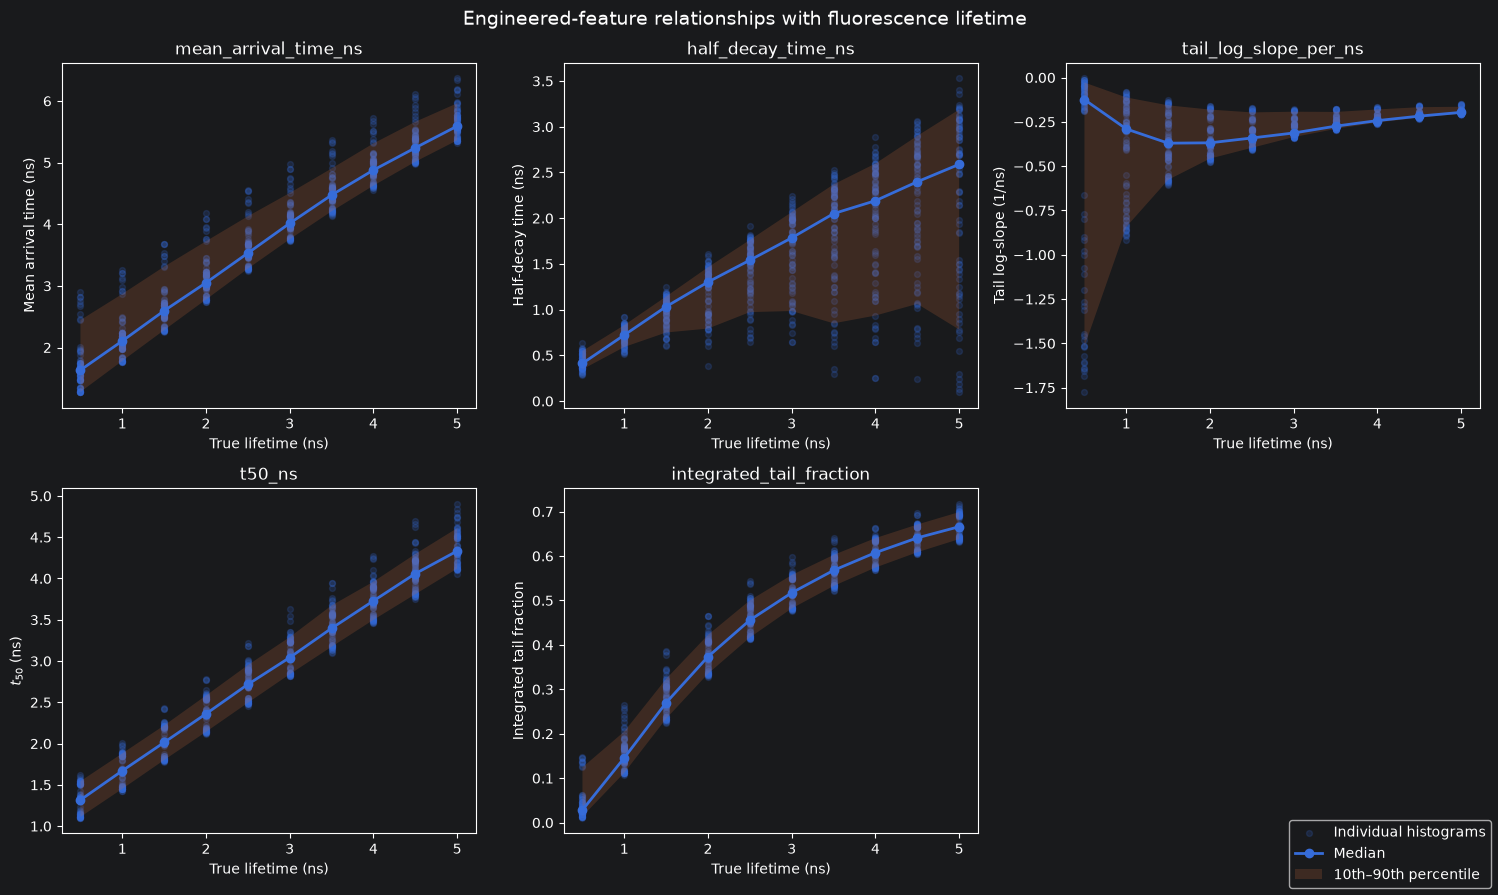

In [18]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9),
)

axes = axes.ravel()

for axis, feature_name in zip(
    axes,
    lifetime_feature_names,
):
    summary = summarize_feature_by_lifetime(
        analysis_table,
        feature_name,
    )

    axis.scatter(
        analysis_table["lifetime_true_ns"],
        analysis_table[feature_name],
        alpha=0.18,
        s=18,
        label="Individual histograms",
    )

    axis.plot(
        summary["lifetime_true_ns"],
        summary["median"],
        marker="o",
        linewidth=2,
        label="Median",
    )

    axis.fill_between(
        summary["lifetime_true_ns"],
        summary["q10"],
        summary["q90"],
        alpha=0.20,
        label="10th–90th percentile",
    )

    axis.set_xlabel(
        "True lifetime (ns)"
    )

    axis.set_ylabel(
        lifetime_feature_labels[
            feature_name
        ]
    )

    axis.set_title(
        feature_name
    )


# The sixth subplot is unused.
axes[-1].axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower right",
)

fig.suptitle(
    "Engineered-feature relationships with fluorescence lifetime",
    fontsize=14,
)

fig.tight_layout()

plt.show()

In [19]:
lifetime_trend_table = pd.DataFrame(
    {
        "lifetime_true_ns": sorted(
            analysis_table[
                "lifetime_true_ns"
            ].unique()
        )
    }
)

for feature_name in lifetime_feature_names:
    summary = summarize_feature_by_lifetime(
        analysis_table,
        feature_name,
    )

    lifetime_trend_table[
        feature_name
    ] = summary["median"].to_numpy()


lifetime_trend_table.round(4)

,lifetime_true_ns,mean_arrival_time_ns,half_decay_time_ns,tail_log_slope_per_ns,t50_ns,integrated_tail_fraction
0,0.5,1.6342,0.4126,-0.1245,1.3174,0.0285
1,1.0,2.1069,0.7225,-0.2900,1.6711,0.1460
2,1.5,2.5969,1.0331,-0.3702,2.0146,0.2700
3,2.0,3.0509,1.3022,-0.3682,2.3608,0.3736
4,2.5,3.5317,1.5409,-0.3410,2.7174,0.4558
5,3.0,4.0154,1.7850,-0.3127,3.0422,0.5173
6,3.5,4.4736,2.0500,-0.2742,3.3968,0.5678
7,4.0,4.8787,2.1912,-0.2428,3.7289,0.6076
8,4.5,5.2393,2.3983,-0.2176,4.0585,0.6409
9,5.0,5.5916,2.5888,-0.1964,4.3329,0.6660


### Interpretation

Several engineered features should exhibit systematic lifetime dependence, but
none is expected to be a perfect lifetime estimator.

A useful distinction is between:

$$
\text{lifetime sensitivity}
$$

and

$$
\text{lifetime specificity}.
$$

A feature is **lifetime-sensitive** if it changes systematically when lifetime
changes.

A feature is **lifetime-specific** only if that change is largely independent
of other physical or instrumental variables.

The vertical spread observed at a fixed lifetime shows that these are not the
same property.

For example, a longer lifetime may increase mean arrival time, but an IRF
temporal shift can also move the mean arrival time. Similarly, background can
increase late-arriving photon weight and therefore change quantities such as
$t_{50}$, tail fraction, and the fitted tail slope.

Thus, a strong lifetime correlation under ideal conditions does not by itself
establish robustness for realistic lifetime inference.

The tail-slope behavior at the shortest lifetimes also illustrates the
importance of the feature definition: when the configured tail begins only
after most of a fast fluorescence decay has vanished, the fitted slope may be
dominated by background and photon-counting fluctuations rather than by the
ideal exponential tail.

## 4. Sensitivity to nuisance variables

The previous section mixed many physical conditions at each lifetime.

We now perform controlled one-variable-at-a-time comparisons.

The true lifetime is fixed at:

$$
\tau = 2.5\ \mathrm{ns}.
$$

Unless a parameter is the one being varied, the reference measurement
condition is:

- signal photons = 25,000;
- background = 0.5 counts/bin;
- IRF FWHM = 0.30 ns;
- IRF shift = 0.00 ns.

Four nuisance sweeps are examined:

1. signal-photon count;
2. background;
3. IRF width;
4. IRF temporal shift.

Because the histograms are Poisson sampled, differences between points include
both the systematic effect of the changed nuisance parameter and statistical
measurement noise.

The objective is therefore not to establish exact invariance, but to identify
which engineered features are particularly sensitive to different measurement
conditions.

In [20]:
REFERENCE_LIFETIME_NS = 2.5
REFERENCE_SIGNAL_PHOTONS = 25_000
REFERENCE_BACKGROUND_PER_BIN = 0.5
REFERENCE_IRF_FWHM_NS = 0.30
REFERENCE_IRF_SHIFT_NS = 0.0

In [21]:
def select_controlled_sweep(
    *,
    varying_parameter: str,
) -> pd.DataFrame:
    """Select a one-variable-at-a-time nuisance sweep."""

    fixed_conditions = {
        "lifetime_true_ns": REFERENCE_LIFETIME_NS,
        "signal_photon_count_target": REFERENCE_SIGNAL_PHOTONS,
        "background_per_bin": REFERENCE_BACKGROUND_PER_BIN,
        "irf_fwhm_ns": REFERENCE_IRF_FWHM_NS,
        "irf_shift_ns": REFERENCE_IRF_SHIFT_NS,
    }

    mask = np.ones(
        len(analysis_table),
        dtype=bool,
    )

    for column_name, reference_value in fixed_conditions.items():
        if column_name == varying_parameter:
            continue

        mask &= np.isclose(
            analysis_table[column_name],
            reference_value,
        )

    sweep = analysis_table.loc[
        mask
    ].copy()

    sweep = sweep.sort_values(
        varying_parameter
    )

    return sweep

In [22]:
photon_count_sweep = select_controlled_sweep(
    varying_parameter="signal_photon_count_target"
)

background_sweep = select_controlled_sweep(
    varying_parameter="background_per_bin"
)

irf_width_sweep = select_controlled_sweep(
    varying_parameter="irf_fwhm_ns"
)

irf_shift_sweep = select_controlled_sweep(
    varying_parameter="irf_shift_ns"
)


assert len(photon_count_sweep) == len(
    signal_photon_counts
)

assert len(background_sweep) == len(
    background_levels
)

assert len(irf_width_sweep) == len(
    irf_fwhm_values_ns
)

assert len(irf_shift_sweep) == len(
    irf_shift_values_ns
)

### 4.1 Signal-photon count

Changing the photon count should strongly affect absolute-intensity features
such as:

- `total_counts`;
- `peak_height`.

In contrast, normalized temporal descriptors such as mean arrival time,
quantiles, or tail fraction are mathematically independent of a pure
multiplicative rescaling of a noiseless histogram.

However, real measured histograms are Poisson sampled.

Lower photon counts therefore increase statistical fluctuations, so even
scale-invariant feature definitions become less stable at low photon count.

In [23]:
photon_count_columns = [
    "signal_photon_count_target",
    "measured_total_counts",
    "total_counts",
    "peak_height",
    "mean_arrival_time_ns",
    "t50_ns",
    "half_decay_time_ns",
    "tail_log_slope_per_ns",
    "integrated_tail_fraction",
]

photon_count_sweep[
    photon_count_columns
].round(4)

,signal_photon_count_target,measured_total_counts,total_counts,peak_height,mean_arrival_time_ns,t50_ns,half_decay_time_ns,tail_log_slope_per_ns,integrated_tail_fraction
337,5000.0,5217.0,5217.0,93.0,3.7589,2.8028,1.1865,-0.2368,0.4752
364,25000.0,25316.0,25316.0,456.0,3.5317,2.7148,1.7571,-0.3419,0.4551
391,100000.0,100057.0,100057.0,1801.0,3.4820,2.6942,1.6225,-0.3917,0.4513


### 4.2 Background

A constant background redistributes the normalized histogram toward a more
uniform temporal distribution.

It can therefore affect several lifetime-related descriptors even though the
true fluorescence lifetime is unchanged.

Late-time features are expected to be particularly vulnerable because
background becomes relatively more important after the fluorescence signal has
decayed.

Potentially sensitive quantities include:

- mean arrival time;
- late quantiles;
- tail fraction;
- early/late ratio;
- tail log-slope.

In [24]:
background_columns = [
    "background_per_bin",
    "total_counts",
    "mean_arrival_time_ns",
    "t50_ns",
    "t90_ns",
    "half_decay_time_ns",
    "tail_log_slope_per_ns",
    "integrated_tail_fraction",
    "early_late_count_ratio",
]

background_sweep[
    background_columns
].round(4)

,background_per_bin,total_counts,mean_arrival_time_ns,t50_ns,t90_ns,half_decay_time_ns,tail_log_slope_per_ns,integrated_tail_fraction,early_late_count_ratio
355,0.0,24813.0,3.4549,2.6799,6.6246,1.7477,-0.3659,0.4482,1.1439
364,0.5,25316.0,3.5317,2.7148,6.8197,1.7571,-0.3419,0.4551,1.0826
373,2.0,25930.0,3.6467,2.7469,7.1149,1.6896,-0.3000,0.4621,1.0486


### 4.3 IRF width

Increasing the IRF FWHM broadens the instrumental temporal response without
changing the underlying fluorescence lifetime.

This should primarily influence features describing the early-time shape and
overall temporal spread.

For example, IRF broadening can modify:

- peak height;
- arrival-time variance;
- half-decay timing;
- early quantiles.

A sufficiently late tail slope may be comparatively less sensitive, but this
depends on where the configured tail region begins relative to the IRF and
fluorescence decay.

In [25]:
irf_width_columns = [
    "irf_fwhm_ns",
    "peak_height",
    "peak_time_ns",
    "mean_arrival_time_ns",
    "arrival_time_variance_ns2",
    "t50_ns",
    "half_decay_time_ns",
    "tail_log_slope_per_ns",
]

irf_width_sweep[
    irf_width_columns
].round(4)

,irf_fwhm_ns,peak_height,peak_time_ns,mean_arrival_time_ns,arrival_time_variance_ns2,t50_ns,half_decay_time_ns,tail_log_slope_per_ns
361,0.15,488.0,1.15,3.4964,6.6287,2.6836,1.5921,-0.3362
364,0.30,456.0,1.15,3.5317,6.6387,2.7148,1.7571,-0.3419
367,0.60,401.0,1.35,3.5217,6.7965,2.6976,1.9148,-0.3410


### 4.4 IRF temporal shift

IRF temporal shift is fundamentally different from temporal broadening.

A shift changes the absolute timing of the measured histogram while leaving
the underlying fluorescence lifetime unchanged.

Absolute temporal-location features such as:

- peak time;
- mean arrival time;
- quantile times;

should therefore respond directly to IRF shift.

By contrast, a feature defined as an elapsed interval relative to the measured
peak, such as `half_decay_time_ns`, may be less sensitive to a pure temporal
translation.

This provides an example of how feature definitions can encode different
degrees of robustness to nuisance variables.

In [26]:
irf_shift_columns = [
    "irf_shift_ns",
    "peak_time_ns",
    "mean_arrival_time_ns",
    "t10_ns",
    "t50_ns",
    "t90_ns",
    "half_decay_time_ns",
    "tail_log_slope_per_ns",
]

irf_shift_sweep[
    irf_shift_columns
].round(4)

,irf_shift_ns,peak_time_ns,mean_arrival_time_ns,t10_ns,t50_ns,t90_ns,half_decay_time_ns,tail_log_slope_per_ns
363,-0.2,1.05,3.3137,1.0118,2.4868,6.6768,1.5395,-0.3371
364,0.0,1.15,3.5317,1.2174,2.7148,6.8197,1.7571,-0.3419
365,0.2,1.45,3.6805,1.4091,2.8687,6.9613,1.4951,-0.3482


In [27]:
def plot_nuisance_sweep(
    sweep: pd.DataFrame,
    x_column: str,
    x_label: str,
    title: str,
) -> None:
    """Plot selected engineered features across one nuisance sweep."""

    fig, axes = plt.subplots(
        1,
        len(lifetime_feature_names),
        figsize=(18, 4),
    )

    for axis, feature_name in zip(
        axes,
        lifetime_feature_names,
    ):
        axis.plot(
            sweep[x_column],
            sweep[feature_name],
            marker="o",
        )

        axis.set_xlabel(
            x_label
        )

        axis.set_ylabel(
            lifetime_feature_labels[
                feature_name
            ]
        )

        axis.set_title(
            feature_name
        )

    fig.suptitle(
        title
    )

    fig.tight_layout()

    plt.show()

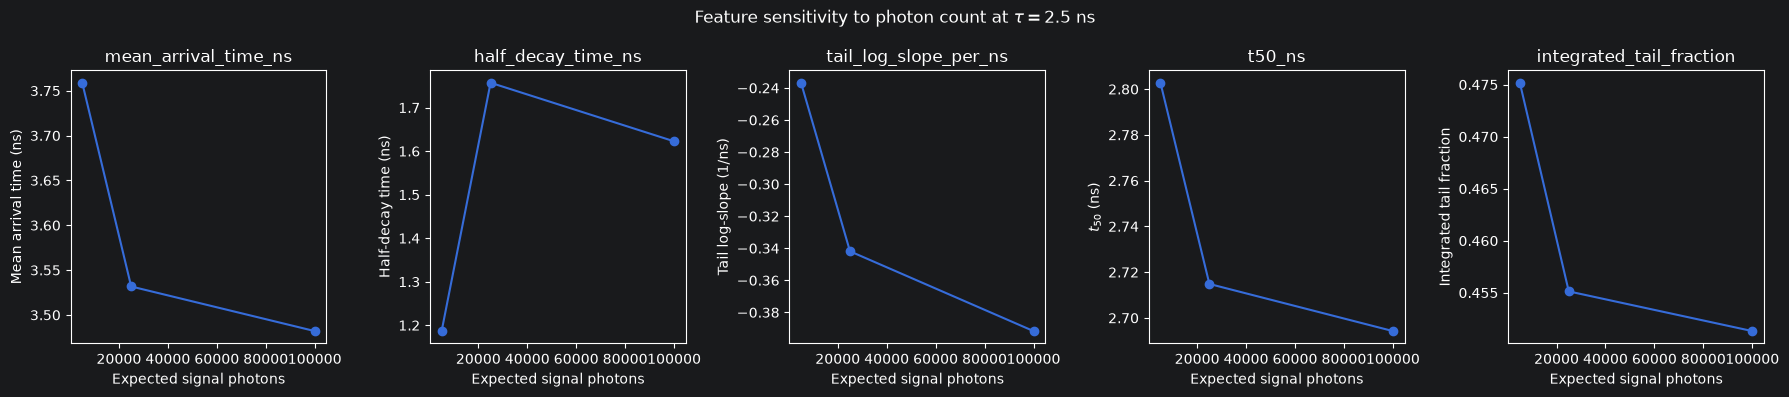

In [28]:
plot_nuisance_sweep(
    photon_count_sweep,
    x_column="signal_photon_count_target",
    x_label="Expected signal photons",
    title=(
        "Feature sensitivity to photon count "
        rf"at $\tau={REFERENCE_LIFETIME_NS:.1f}$ ns"
    ),
)

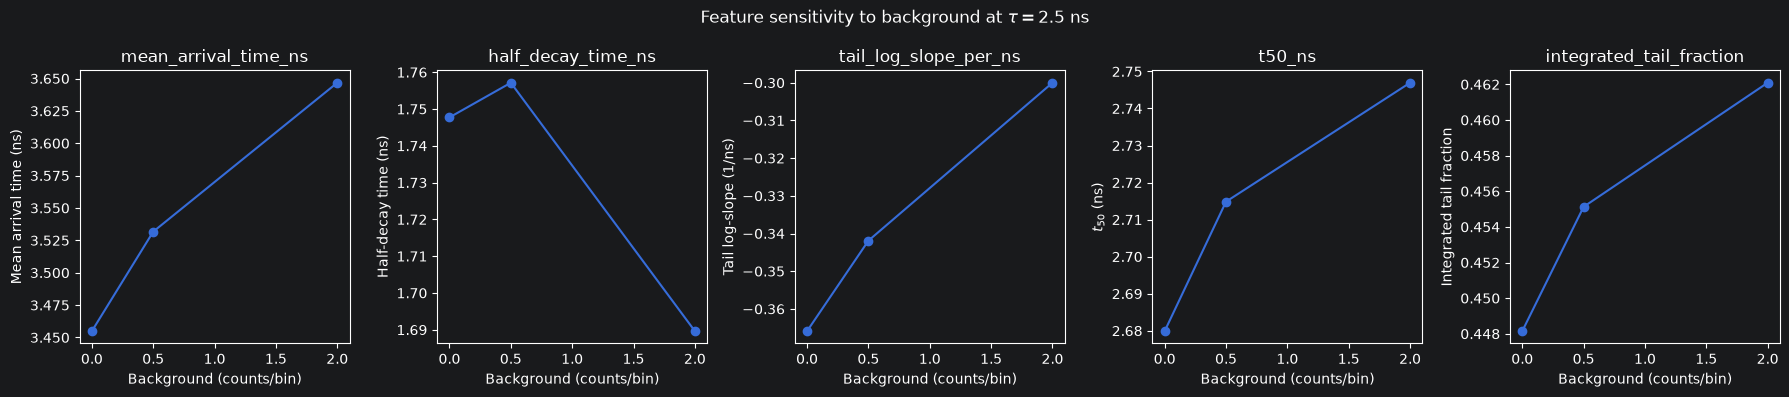

In [29]:
plot_nuisance_sweep(
    background_sweep,
    x_column="background_per_bin",
    x_label="Background (counts/bin)",
    title=(
        "Feature sensitivity to background "
        rf"at $\tau={REFERENCE_LIFETIME_NS:.1f}$ ns"
    ),
)

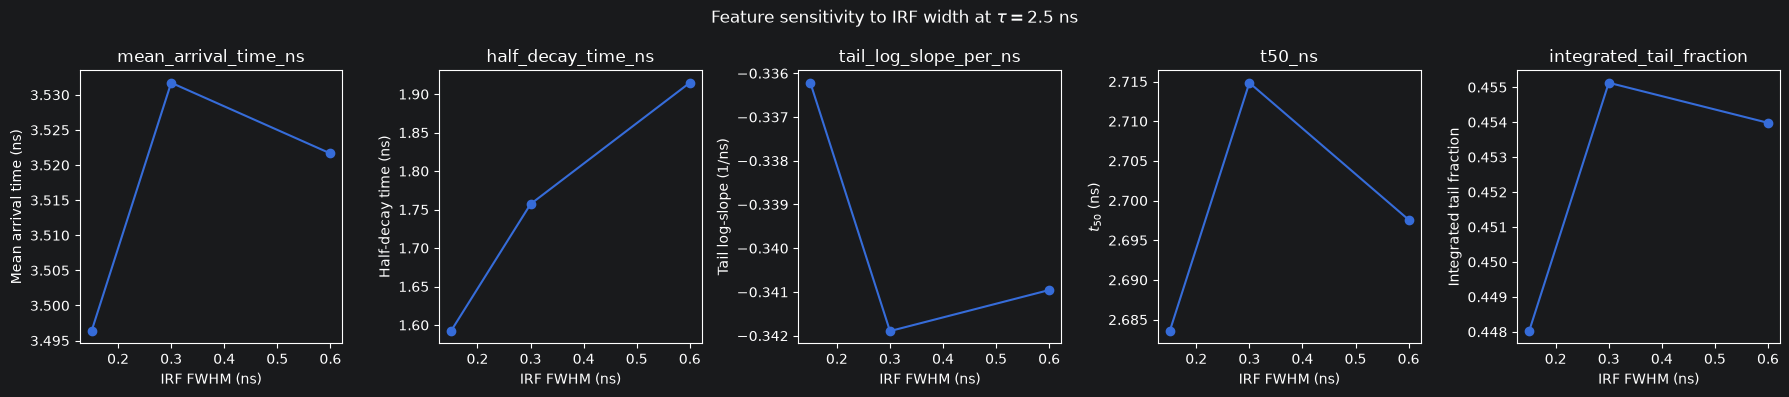

In [30]:
plot_nuisance_sweep(
    irf_width_sweep,
    x_column="irf_fwhm_ns",
    x_label="IRF FWHM (ns)",
    title=(
        "Feature sensitivity to IRF width "
        rf"at $\tau={REFERENCE_LIFETIME_NS:.1f}$ ns"
    ),
)

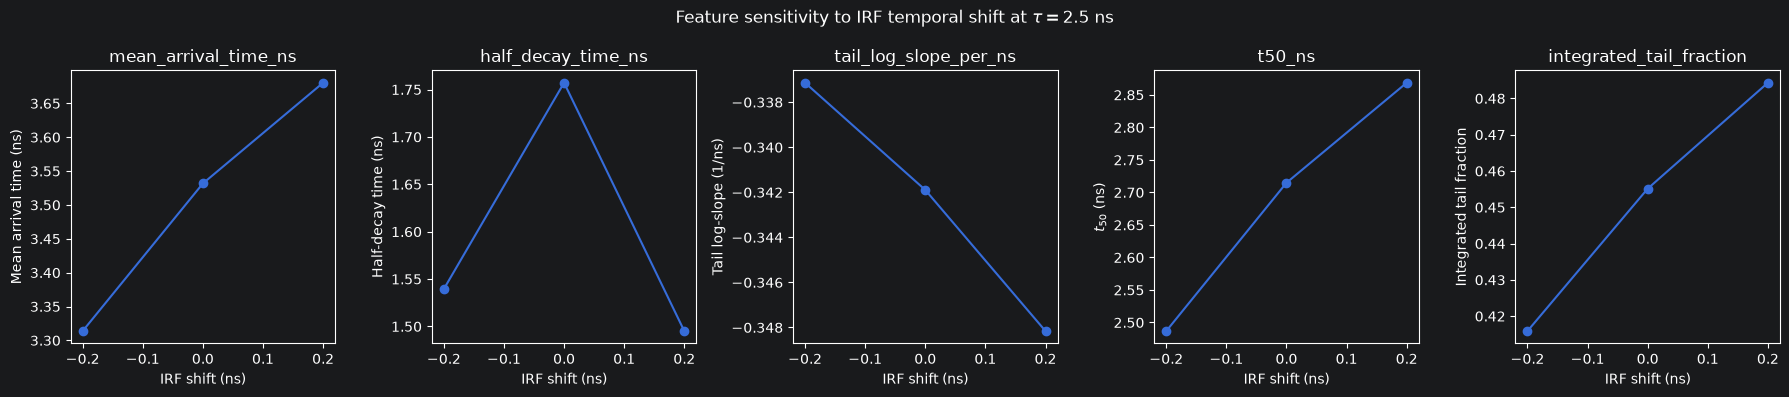

In [31]:
plot_nuisance_sweep(
    irf_shift_sweep,
    x_column="irf_shift_ns",
    x_label="IRF shift (ns)",
    title=(
        "Feature sensitivity to IRF temporal shift "
        rf"at $\tau={REFERENCE_LIFETIME_NS:.1f}$ ns"
    ),
)

### What the nuisance analysis shows

No engineered feature should be assumed to encode fluorescence lifetime alone.

The different descriptors mix physical information in different ways.

For example:

- absolute-count features naturally respond to photon-count level;
- temporal-location features respond to both lifetime and IRF shift;
- width-related features can respond to both fluorescence decay and IRF
  broadening;
- late-time features can be strongly affected by background;
- low photon counts increase the statistical variability of otherwise
  scale-invariant feature definitions.

This does not make engineered features unsuitable for lifetime inference.

Instead, it defines the inference problem more realistically:

$$
\text{measured histogram}
=
f(
\tau,
N_{\mathrm{photons}},
B,
\mathrm{IRF\ width},
\mathrm{IRF\ shift},
\ldots
)
+
\text{measurement noise}.
$$

A useful estimator must learn or model which changes are associated with
lifetime and which arise from nuisance variables.

This is one reason that physically interpretable features remain valuable even
if a later machine-learning model ultimately performs better using the full
histogram shape.

The present plots quantify feature behavior only. They do not yet measure
prediction accuracy or establish which representation is optimal.

## 5. Total-normalized histogram representation

Engineered features compress each TCSPC histogram into a small number of
physically motivated descriptors.

An alternative is to retain the complete histogram shape and use every time
bin as an input feature.

For a histogram with counts

$$
N_1, N_2, \ldots, N_M,
$$

total normalization defines

$$
x_i
=
\frac{N_i}{\sum_j N_j}.
$$

The resulting histogram satisfies

$$
\sum_i x_i = 1.
$$

This representation preserves the relative temporal distribution of detected
photons while deliberately removing absolute photon-count information.

This is useful when the objective is to compare decay shapes independently of
overall intensity, but it also means that photon-count level is no longer
directly available to a model using only the normalized bins.

In [32]:
X_histogram = normalize_histogram_batch(
    histograms=histograms,
    mode=CountNormalization.TOTAL,
)

print(
    "Raw histogram matrix:",
    histograms.shape,
)

print(
    "Normalized histogram matrix:",
    X_histogram.shape,
)

np.testing.assert_allclose(
    X_histogram.sum(axis=1),
    np.ones(X_histogram.shape[0]),
)

Raw histogram matrix: (810, 400)
Normalized histogram matrix: (810, 400)


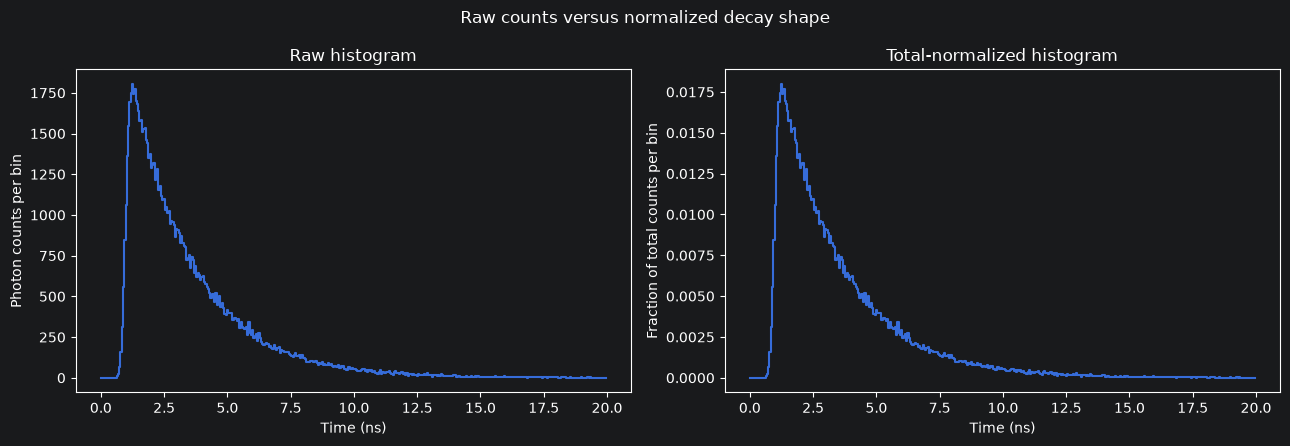

In [33]:
normalization_example_id = find_curve_id(
    lifetime_ns=2.5,
    signal_photon_count=100_000,
    background_per_bin=0.0,
    irf_fwhm_ns=0.30,
    irf_shift_ns=0.0,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
)

axes[0].plot(
    time,
    histograms[normalization_example_id],
    drawstyle="steps-mid",
)

axes[0].set_title(
    "Raw histogram"
)

axes[0].set_xlabel(
    "Time (ns)"
)

axes[0].set_ylabel(
    "Photon counts per bin"
)


axes[1].plot(
    time,
    X_histogram[normalization_example_id],
    drawstyle="steps-mid",
)

axes[1].set_title(
    "Total-normalized histogram"
)

axes[1].set_xlabel(
    "Time (ns)"
)

axes[1].set_ylabel(
    "Fraction of total counts per bin"
)


fig.suptitle(
    "Raw counts versus normalized decay shape"
)

fig.tight_layout()

plt.show()

### Exact count-scaling invariance

To isolate the mathematical effect of total normalization, consider one
measured histogram and an exact scaled copy:

$$
N_i' = cN_i.
$$

The raw histograms have different absolute intensities:

$$
\sum_i N_i'
=
c\sum_i N_i.
$$

However,

$$
\frac{N_i'}{\sum_j N_j'}
=
\frac{cN_i}{c\sum_j N_j}
=
\frac{N_i}{\sum_j N_j}.
$$

Therefore total normalization removes a pure multiplicative count scale
exactly.

This controlled example is different from comparing two independent
measurements at different photon-count levels, because independent Poisson
realizations will still differ statistically after normalization.

In [34]:
reference_histogram = histograms[
    normalization_example_id
]

scale_factor = 5

scaled_histograms = np.vstack(
    [
        reference_histogram,
        scale_factor * reference_histogram,
    ]
)

scaled_normalized = normalize_histogram_batch(
    histograms=scaled_histograms,
    mode=CountNormalization.TOTAL,
)

print(
    "Original total counts:",
    scaled_histograms[0].sum(),
)

print(
    "Scaled total counts:",
    scaled_histograms[1].sum(),
)

print(
    "Raw count ratio:",
    (
        scaled_histograms[1].sum()
        / scaled_histograms[0].sum()
    ),
)

print(
    "Maximum normalized-bin difference:",
    np.max(
        np.abs(
            scaled_normalized[1]
            - scaled_normalized[0]
        )
    ),
)

np.testing.assert_allclose(
    scaled_normalized[0],
    scaled_normalized[1],
)

Original total counts: 100308
Scaled total counts: 501540
Raw count ratio: 5.0
Maximum normalized-bin difference: 0.0


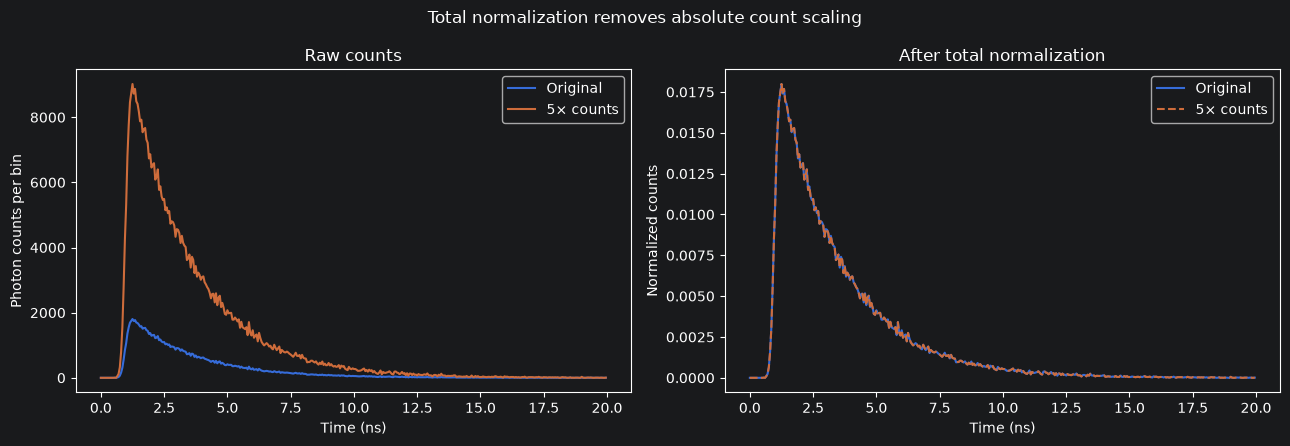

In [35]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
)

axes[0].plot(
    time,
    scaled_histograms[0],
    label="Original",
)

axes[0].plot(
    time,
    scaled_histograms[1],
    label=f"{scale_factor}× counts",
)

axes[0].set_title(
    "Raw counts"
)

axes[0].set_xlabel(
    "Time (ns)"
)

axes[0].set_ylabel(
    "Photon counts per bin"
)

axes[0].legend()


axes[1].plot(
    time,
    scaled_normalized[0],
    label="Original",
)

axes[1].plot(
    time,
    scaled_normalized[1],
    linestyle="--",
    label=f"{scale_factor}× counts",
)

axes[1].set_title(
    "After total normalization"
)

axes[1].set_xlabel(
    "Time (ns)"
)

axes[1].set_ylabel(
    "Normalized counts"
)

axes[1].legend()


fig.suptitle(
    "Total normalization removes absolute count scaling"
)

fig.tight_layout()

plt.show()

### Common train/test sample split

All machine-learning representations must describe the same physical samples.

We therefore define one train/test split at the sample level and reuse it for:

- engineered features;
- normalized histogram bins;
- PCA-compressed histograms.

The split is stratified by lifetime so that all lifetime values remain
represented in both subsets.

No representation-specific resampling is allowed.

This separation is particularly important for PCA because PCA is a learned
transformation. It must be fitted using the training histograms only.

In [36]:
sample_indices = np.arange(
    len(metadata)
)

target_lifetime = metadata[
    "lifetime_true_ns"
].to_numpy(
    dtype=np.float64
)

train_indices, test_indices = train_test_split(
    sample_indices,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=target_lifetime,
)

print(
    "Training samples:",
    len(train_indices),
)

print(
    "Test samples:",
    len(test_indices),
)

Training samples: 648
Test samples: 162


## 6. PCA-compressed histogram representation

Normalized histograms retain the complete temporal decay shape, but they are
high-dimensional.

For the present dataset:

$$
M = 400
$$

time bins produce 400 input features per histogram.

Neighboring TCSPC bins are also strongly correlated because fluorescence decay
and IRF broadening vary smoothly in time.

Principal component analysis (PCA) constructs orthogonal directions of maximum
variance in the normalized histogram data.

For a centered histogram vector $\mathbf{x}$,

$$
\mathbf{z}
=
\mathbf{W}
(\mathbf{x}-\boldsymbol{\mu}),
$$

where the rows of $\mathbf{W}$ are principal-component directions learned
from the training data.

PCA is unsupervised:

- it does not use the true lifetime during fitting;
- it maximizes histogram variance, not lifetime information.

Therefore a component explaining large histogram variance is not necessarily
the component most useful for lifetime estimation.

In [37]:
PCA_N_COMPONENTS = 20

pca = fit_pca_representation(
    X_train=X_histogram[
        train_indices
    ],
    n_components=PCA_N_COMPONENTS,
)

X_pca = transform_pca_representation(
    pca=pca,
    X=X_histogram,
)

print(
    "PCA representation shape:",
    X_pca.shape,
)

assert X_pca.shape == (
    len(histograms),
    PCA_N_COMPONENTS,
)

PCA representation shape: (810, 20)


In [38]:
explained_variance_ratio = (
    pca.explained_variance_ratio_
)

cumulative_variance = (
    cumulative_explained_variance(
        pca
    )
)

component_numbers = np.arange(
    1,
    PCA_N_COMPONENTS + 1,
)

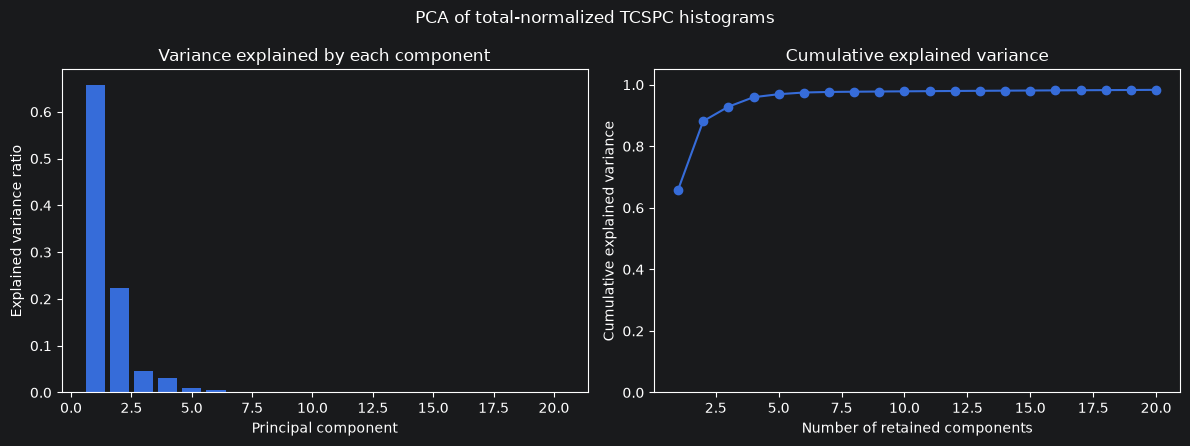

In [39]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

axes[0].bar(
    component_numbers,
    explained_variance_ratio,
)

axes[0].set_xlabel(
    "Principal component"
)

axes[0].set_ylabel(
    "Explained variance ratio"
)

axes[0].set_title(
    "Variance explained by each component"
)


axes[1].plot(
    component_numbers,
    cumulative_variance,
    marker="o",
)

axes[1].set_xlabel(
    "Number of retained components"
)

axes[1].set_ylabel(
    "Cumulative explained variance"
)

axes[1].set_ylim(
    0.0,
    1.05,
)

axes[1].set_title(
    "Cumulative explained variance"
)


fig.suptitle(
    "PCA of total-normalized TCSPC histograms"
)

fig.tight_layout()

plt.show()

In [40]:
for n_components in [
    1,
    2,
    3,
    5,
    10,
    20,
]:
    print(
        f"{n_components:2d} components: "
        f"{cumulative_variance[n_components - 1]:.4f}"
    )

 1 components: 0.6579
 2 components: 0.8816
 3 components: 0.9285
 5 components: 0.9692
10 components: 0.9786
20 components: 0.9833


### Temporal structure of the principal components

Each PCA component contains one coefficient for every histogram time bin.

The components should not be interpreted as physical decay curves.

Instead, they describe directions in histogram space along which the normalized
measurements vary most strongly around the training-set mean.

Positive and negative component weights indicate temporal regions that vary in
opposing directions.

The overall sign of a PCA component is arbitrary: multiplying both a component
and its corresponding scores by \(-1\) represents the same PCA solution.

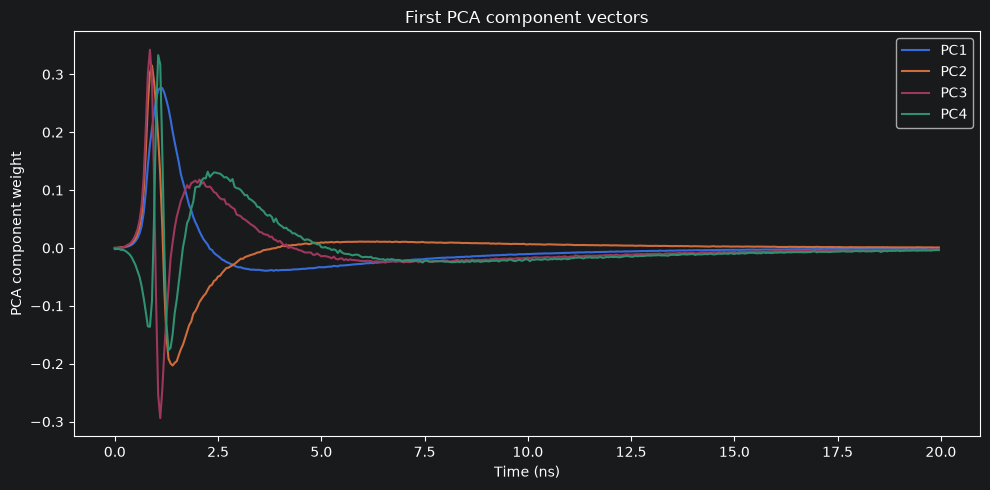

In [41]:
N_COMPONENTS_TO_PLOT = 4

fig, ax = plt.subplots(
    figsize=(10, 5),
)

for component_index in range(
    N_COMPONENTS_TO_PLOT
):
    ax.plot(
        time,
        pca.components_[
            component_index
        ],
        label=(
            f"PC{component_index + 1}"
        ),
    )

ax.set_xlabel(
    "Time (ns)"
)

ax.set_ylabel(
    "PCA component weight"
)

ax.set_title(
    "First PCA component vectors"
)

ax.legend()

fig.tight_layout()

plt.show()

### PCA score space

We can also inspect samples in the first two principal-component coordinates.

The points are colored by true lifetime only for visualization.

Lifetime was not supplied to PCA during fitting.

If samples organize systematically by lifetime in PC space, this indicates
that lifetime contributes to important directions of histogram variation.
However, separation need not be perfect because nuisance variables also
contribute to the variance captured by PCA.

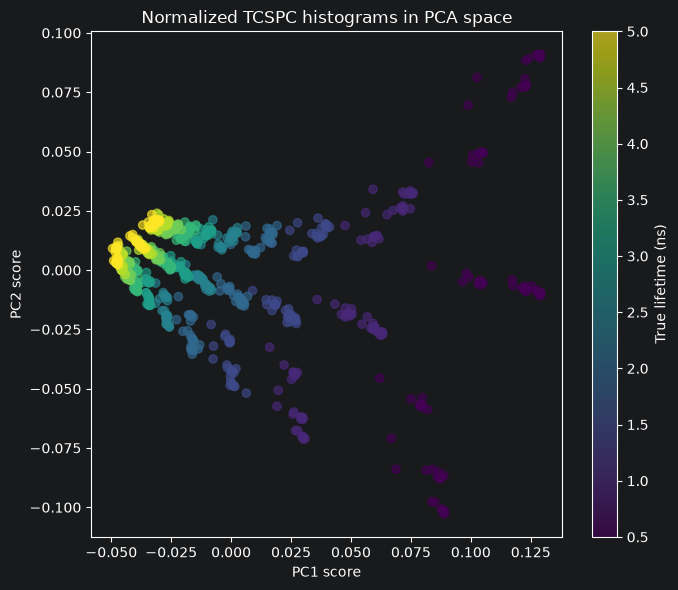

In [42]:
fig, ax = plt.subplots(
    figsize=(7, 6),
)

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=target_lifetime,
    alpha=0.65,
)

ax.set_xlabel(
    "PC1 score"
)

ax.set_ylabel(
    "PC2 score"
)

ax.set_title(
    "Normalized TCSPC histograms in PCA space"
)

colorbar = fig.colorbar(
    scatter,
    ax=ax,
)

colorbar.set_label(
    "True lifetime (ns)"
)

fig.tight_layout()

plt.show()

## 7. Comparing the three ML representations

We can now construct three different numerical descriptions of exactly the same
810 simulated TCSPC measurements.

### Engineered physical features

Each histogram is compressed into a small set of manually defined physical
descriptors.

### Normalized histogram bins

Every normalized time bin is retained directly as an input feature.

### PCA-compressed histograms

The normalized histogram is projected onto principal-component directions
learned from the training data only.

The three representations differ in dimensionality and scientific
interpretability, but their rows correspond to exactly the same samples.

In [43]:
X_engineered = feature_table.to_numpy(
    dtype=np.float64
)

X_histogram = np.asarray(
    X_histogram,
    dtype=np.float64,
)

X_pca = np.asarray(
    X_pca,
    dtype=np.float64,
)


print(
    "X_engineered:",
    X_engineered.shape,
)

print(
    "X_histogram:",
    X_histogram.shape,
)

print(
    "X_pca:",
    X_pca.shape,
)

X_engineered: (810, 15)
X_histogram: (810, 400)
X_pca: (810, 20)


In [44]:
X_engineered_train = X_engineered[
    train_indices
]

X_engineered_test = X_engineered[
    test_indices
]


X_histogram_train = X_histogram[
    train_indices
]

X_histogram_test = X_histogram[
    test_indices
]


X_pca_train = X_pca[
    train_indices
]

X_pca_test = X_pca[
    test_indices
]


y_train = target_lifetime[
    train_indices
]

y_test = target_lifetime[
    test_indices
]

In [45]:
assert X_engineered_train.shape[0] == len(
    y_train
)

assert X_histogram_train.shape[0] == len(
    y_train
)

assert X_pca_train.shape[0] == len(
    y_train
)


assert X_engineered_test.shape[0] == len(
    y_test
)

assert X_histogram_test.shape[0] == len(
    y_test
)

assert X_pca_test.shape[0] == len(
    y_test
)

In [46]:
metadata_train = metadata.iloc[
    train_indices
].copy()

metadata_test = metadata.iloc[
    test_indices
].copy()

In [47]:
representation_summary = pd.DataFrame(
    {
        "representation": [
            "Engineered features",
            "Normalized histogram",
            "PCA histogram",
        ],
        "n_samples": [
            X_engineered.shape[0],
            X_histogram.shape[0],
            X_pca.shape[0],
        ],
        "n_features": [
            X_engineered.shape[1],
            X_histogram.shape[1],
            X_pca.shape[1],
        ],
        "absolute_count_information": [
            "Yes",
            "No",
            "No",
        ],
        "physical_interpretability": [
            "High",
            "Medium",
            "Lower",
        ],
        "learned_transformation": [
            "No",
            "No",
            "Yes — PCA",
        ],
    }
)

representation_summary

,representation,n_samples,n_features,absolute_count_information,physical_interpretability,learned_transformation
0,Engineered features,810,15,Yes,High,No
1,Normalized histogram,810,400,No,Medium,No
2,PCA histogram,810,20,No,Lower,Yes — PCA


### Engineered physical features

**Advantages**

- low dimensional;
- physically interpretable;
- individually inspectable;
- directly connect model inputs to properties of the measured histogram;
- provide useful baselines for understanding what information an estimator may
  exploit.

**Limitations**

- depend on manually chosen definitions;
- tail and early/late features depend on configured temporal boundaries;
- potentially useful histogram structure may be discarded;
- several features respond to nuisance variables as well as lifetime.

---

### Total-normalized histogram bins

**Advantages**

- preserve detailed temporal decay shape;
- require minimal manual feature design;
- allow models to determine which time regions are useful.

**Limitations**

- high dimensional;
- neighboring bins are strongly correlated;
- sensitive to temporal alignment and IRF variation;
- total normalization deliberately removes absolute photon-count information.

Thus,

$$
N_i
$$

and

$$
\frac{N_i}{\sum_j N_j}
$$

represent physically different information.

---

### PCA-compressed histograms

**Advantages**

- lower dimensional than the full histogram;
- reduce correlated histogram-bin structure;
- capture dominant modes of variation in the training histograms.

**Limitations**

- principal components are less physically interpretable;
- PCA maximizes variance rather than lifetime information;
- important low-variance lifetime information could in principle be discarded;
- PCA is a learned transformation and therefore introduces a potential source
  of data leakage.

PCA must consequently be fitted using training data only.

The fitted transformer may then be applied to both training and test
histograms.

## Week 6 conclusions

This notebook establishes several principles for machine-learning analysis of
TCSPC data.

### 1. Feature engineering is part of the scientific model

Quantities such as tail fraction or early/late count ratio are meaningful only
together with their explicit temporal definitions.

### 2. Feature extraction and preprocessing are different operations

Engineered features should not silently trigger background subtraction,
alignment, cropping, normalization, or rebinning.

The appropriate preprocessing depends on the intended analysis.

### 3. Absolute intensity and normalized temporal shape contain different information

Raw photon counts preserve photon statistics and absolute intensity.

Total-normalized histograms preserve relative temporal shape but deliberately
discard a pure multiplicative count scale.

### 4. Physically interpretable features remain useful even if another representation performs better

They provide scientific baselines and help identify what information later
models may be exploiting.

### 5. PCA is dimensionality reduction, not lifetime estimation

PCA identifies directions of large histogram variance without using lifetime
labels.

High explained variance therefore does not guarantee high lifetime-prediction
performance.

### 6. Learned transformations must never see the test set during fitting

This applies to:

- PCA;
- feature scalers;
- feature selection;
- hyperparameter tuning;
- machine-learning models.

### 7. Nuisance-variable dependence must be measured

Features that correlate with lifetime under ideal conditions can also respond
to photon statistics, background, IRF broadening, and temporal shift.

The resulting lifetime-inference problem is therefore multivariate.

---

Week 6 provides three aligned representations:

$$
X_{\mathrm{engineered}},
\qquad
X_{\mathrm{histogram}},
\qquad
X_{\mathrm{PCA}},
$$

with the same:

- physical samples;
- train/test split;
- lifetime targets;
- evaluation metadata.

This establishes the experimental foundation for Week 7, where the question
changes from

> How should a TCSPC histogram be represented?

to

> How accurately and robustly can different estimators infer lifetime from
> those representations?